In [1]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Literal
import colorsys

In [2]:
os.getcwd()

'/home/skandabhairava/Desktop/MFT_FL/notebooks'

In [3]:
# Define your known tags (easy to expand anytime)
KNOWN_TAGS = {
    "attack_type": ["backdoor60", "backdoor40", "lblswitch60", "lblswitch40", "labelswitch60", 
                    "labelswitch40", "majoritybyz40", "majoritybyz60", "subtle40", "subtle60", "alie40", "alie60", "normal",
                    "late_lblswitch60", "late_backdoor60", "late_subtle60", "late_alie60"
                   ],
    "protocol_type": ["fedattract", "cap", "fedavg"],
    "data_type": ["pathalogical", "pathological", "d0-3", "d1", "dropout50"]
}

similar_tag = {
    "lblswitch40": "labelswitch40",
    "lblswitch60": "labelswitch60",
    "late_lblswitch60": "late_labelswitch60",
    "subtle40": "majoritybyz40",
    "subtle60": "majoritybyz60",
    "late_subtle60": "late_majoritybyz60",
}

def extract_metadata(folder_name):
    name_lower = folder_name.lower()
    meta = {}
    for category, tags in KNOWN_TAGS.items():
        found = [tag for tag in tags if tag in name_lower]
        if len(found) == 0:
            raise

        if len(found) > 1:
            found = list(sorted(found, key=lambda k: len(k), reverse=True))
        
        tag = similar_tag.get(found[0], found[0])
        # print(f"{category} -> {category2}")
        meta[category] = tag if found else "unknown"
    return meta

def parse_run_log(log_path):
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()

    # Client breakdown
    client_matches = re.findall(r"Client\s+\d+\s+has been assigned type:\s*([^\r\n]+)", content)
    normal_count = sum(1 for c in client_matches if c.strip() == "normal")
    total_clients = len(client_matches)
    malicious_count = total_clients - normal_count
    normal_pct = (normal_count / total_clients * 100) if total_clients > 0 else 0.0

    total_bigo_time = re.search(r"Total BigO time:\s*(\d+)", content)

    client_stats = {
        "total_clients": total_clients,
        "normal_clients": normal_count,
        "malicious_clients": malicious_count,
        "normal_pct": normal_pct,
        "malicious_pct": 100 - normal_pct if total_clients > 0 else 0.0,
        "total_bigo": total_bigo_time.group(1)
    }

    # Rounds breakdown
    rounds_data = []
    round_blocks = re.split(r"(?:\n|^)\s*(\d+)/\d+:\s*", content)
    
    if len(round_blocks) > 1:
        for i in range(1, len(round_blocks), 2):
            epoch = int(round_blocks[i])
            block = round_blocks[i + 1]

            train_time = re.search(r"Time taken to train:\s*([\d\.]+)s", block)
            bigo_time = re.search(r"Big O time:\s*(\d+)", block)
            bigo_space = re.search(r"Big O space:\s*(\d+)", block)
            algo_time = re.search(r"Time taken algorithm model:\s*([\d\.]+)", block)
            eval_acc = re.search(r"Accuracy:\s*([\d\.]+)%", block)

            rounds_data.append({
                "epoch": epoch,
                "train_time_s": float(train_time.group(1)) if train_time else None,
                "eval_accuracy": float(eval_acc.group(1)) if eval_acc else None,
                "bigo_time": int(bigo_time.group(1)) if bigo_time else None,
                "bigo_space": int(bigo_space.group(1)) if bigo_space else None,
                "algo_time_s": float(algo_time.group(1)) if algo_time else None
            })

    client_stats["final_accuracy"] = rounds_data[-1]["eval_accuracy"]
    return client_stats, pd.DataFrame(rounds_data)

def load_all_runs(root_dir="./"):
    records = []
    for entry in os.scandir(root_dir):
        if entry.is_dir() and entry.name.startswith("RUN_"):
            log_path = Path(entry.path) / "run.log"
            if log_path.exists():
                meta = extract_metadata(entry.name)
                client_stats, df_rounds = parse_run_log(log_path)
                records.append({
                    "folder_name": entry.name,
                    **meta,
                    **client_stats,
                    "df_rounds": df_rounds
                })
    return pd.DataFrame(records)

In [ ]:
# Load into memory once
DF_RUNS = load_all_runs(root_dir="../logs/")

In [4]:
DF_RUNS = pd.read_pickle('df_runs.pkl')

# DF_RUNS.to_pickle('df_runs.pkl')

In [5]:
def analyze_run(attack=None, protocol=None, data_type=None, run_index=0, steps_split_fedattract=10, late_attack_start=50, return_only=None|Literal['eval_accuracy', 'bigo', 'total_bigo', 'algo_time_s', 'final_accuracy']):
    """
    Filters runs based on chosen variables and displays stats + plots.
    Pass None to any argument to leave it unconstrained.
    """
    filtered = DF_RUNS.copy()
    
    if attack:
        filtered = filtered[filtered["attack_type"] == attack.lower()]
    if protocol:
        filtered = filtered[filtered["protocol_type"] == protocol.lower()]
    if data_type:
        filtered = filtered[filtered["data_type"] == data_type.lower()]
        
    if filtered.empty:
        print(f"No runs found matching: attack='{attack}', protocol='{protocol}', data_type='{data_type}'")
        return None
    
    if len(filtered) > 1:
        print(f"Found {len(filtered)} matching runs. Displaying run index {run_index}:")
        
    row = filtered.iloc[run_index]
    df_rounds = row["df_rounds"]

    if return_only == "eval_accuracy":
        return df_rounds["eval_accuracy"]
    elif return_only == "bigo":
        return df_rounds["bigo_time"]
    elif return_only == "total_bigo":
        return row['total_bigo']
    elif return_only == "algo_time_s":
        return row['algo_time_s']
    elif return_only == "final_accuracy":
        return row['final_accuracy']
    elif return_only == "all":
        return row

    # 1. Print Client Stats
    print("=" * 65)
    print(f"RUN: {row['folder_name']}")
    print(f"Configuration -> Attack: {row['attack_type']} | Protocol: {row['protocol_type']} | Data: {row['data_type']}")
    print("-" * 65)
    print(f"Total Clients:     {row['total_clients']}")
    print(f"Normal Clients:    {row['normal_clients']} ({row['normal_pct']:.2f}%)")
    print(f"Malicious Clients: {row['malicious_clients']} ({row['malicious_pct']:.2f}%)")
    print(f"Total BigO Time: {row['total_bigo']}")
    print(f"Final Acc: {row['final_accuracy']}%")
    print("=" * 65)

    if protocol == "fedattract":
        splits_vline_idx = list(range(0, len(df_rounds["epoch"])+1, steps_split_fedattract))[1:]
    
    # 2. Plot Epoch Metrics
    if not df_rounds.empty:
        fig, axs = plt.subplots(2, 2, figsize=(13, 7))
        fig.suptitle(f"{row['folder_name']}", fontsize=11)

        # Accuracy
        axs[0, 0].plot(df_rounds["epoch"], df_rounds["eval_accuracy"], label="Eval Acc (%)", color="teal", marker="o", markersize=3)
        axs[0, 0].set_title("Accuracy per Epoch")
        axs[0, 0].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[0, 0].axvline(split, c="g")
        if "late" in attack:
            axs[0, 0].axvline(late_attack_start, c="r")
        axs[0, 0].grid(True, linestyle=":", alpha=0.6)
        axs[0, 0].legend()

        # Big O Time
        axs[0, 1].plot(df_rounds["epoch"], df_rounds["bigo_time"], color="crimson", marker="s", markersize=3)
        axs[0, 1].set_title("Big O Time")
        axs[0, 1].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[0, 1].axvline(split, c="g")
        if "late" in attack:
            axs[0, 1].axvline(late_attack_start, c="r")
        axs[0, 1].grid(True, linestyle=":", alpha=0.6)

        # Big O Space
        axs[1, 0].plot(df_rounds["epoch"], df_rounds["bigo_space"], color="darkorange", marker="^", markersize=3)
        axs[1, 0].set_title("Big O Space")
        axs[1, 0].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[1, 0].axvline(split, c="g")
        if "late" in attack:
            axs[1, 0].axvline(late_attack_start, c="r")
        axs[1, 0].grid(True, linestyle=":", alpha=0.6)

        # Algorithm Time
        axs[1, 1].plot(df_rounds["epoch"], df_rounds["algo_time_s"], color="purple", marker="d", markersize=3)
        axs[1, 1].set_title("Algorithm Execution Time (s)")
        axs[1, 1].set_xlabel("Epoch")
        if protocol == "fedattract":
            for split in splits_vline_idx:
                axs[1, 1].axvline(split, c="g")
        if "late" in attack:
            axs[1, 1].axvline(late_attack_start, c="r")
        axs[1, 1].grid(True, linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.show()
        
    return row

In [54]:
def unique_cols(n):
    colors = []

    min_distance = 0.4  # Increase this for more separation
    
    while len(colors) < n:
        # Random HSV
        h = np.random.rand()
        s = 1.0    # high saturation
        v = np.random.uniform(0.5, 0.75)    # dark colors
    
        rgb = np.array(colorsys.hsv_to_rgb(h, s, v))
    
        # Make sure this color is sufficiently different
        if all(np.linalg.norm(rgb - c) >= min_distance for c in colors):
            colors.append(rgb)

    return np.array(colors)

In [24]:
def compare_attacks(
    attack: tuple[str, ...]=None, 
    protocol: str=None, 
    data_type=None, 
    run_index=0, 
    steps_split_fedattract=10,
    late_attack_start=50, 
):    
    rows = {}
    splits_vline = []
    for i, a in enumerate(attack):
        rows[a] = analyze_run(
            a, 
            protocol, 
            data_type, 
            run_index, 
            steps_split_fedattract, 
            late_attack_start, 
            return_only='all'
        )['df_rounds'].to_dict()
        rows[a]['c'] = i
        
    if protocol == "fedattract":
        max_epoch = max(len(df['epoch']) for df in rows.values())
        splits_vline = (list(range(0, max_epoch+1, steps_split_fedattract))[1:])

    unique_colors = unique_cols(len(rows))
    
    fig, axs = plt.subplots(2, 2, figsize=(13, 7))
    fig.suptitle(f"Comparison b/w Attacks", fontsize=11)

    # Accuracy
    for att, dfr in rows.items():
        axs[0, 0].plot(dfr["epoch"].values(), dfr["eval_accuracy"].values(), marker="o", markersize=3, label=att, c=unique_colors[dfr['c']])
    
    for split in splits_vline:
        axs[0, 0].axvline(split, c='teal')
        
    axs[0, 0].set_title("Accuracy per Epoch")
    axs[0, 0].set_xlabel("Epoch")
    
    if "late" in attack:
        axs[0, 0].axvline(late_attack_start, c="r")
        
    axs[0, 0].grid(True, linestyle=":", alpha=0.6)
    axs[0, 0].legend()

    # Big O Time
    for att, dfr in rows.items():
        axs[0, 1].plot(dfr["epoch"].values(), dfr["bigo_time"].values(), marker="o", markersize=3, label=att, c=unique_colors[dfr['c']])
    
    for split in splits_vline:
        axs[0, 1].axvline(split, c='teal')
        
    axs[0, 1].set_title("Big O Time")
    axs[0, 1].set_xlabel("Epoch")
    
    if "late" in attack:
        axs[0, 1].axvline(late_attack_start, c="r")
    axs[0, 1].grid(True, linestyle=":", alpha=0.6)

    # Big O Space
    for att, dfr in rows.items():
        axs[1, 0].plot(dfr["epoch"].values(), dfr["bigo_space"].values(), marker="o", markersize=3, label=att, c=unique_colors[dfr['c']])
    
    for split in splits_vline:
        axs[1, 0].axvline(split, c='teal')
        
    axs[1, 0].set_title("Big O Space")
    axs[1, 0].set_xlabel("Epoch")
    if "late" in attack:
        axs[1, 0].axvline(late_attack_start, c="r")
    axs[1, 0].grid(True, linestyle=":", alpha=0.6)

    # Algorithm Time
    for att, dfr in rows.items():
        axs[1, 1].plot(dfr["epoch"].values(), dfr["algo_time_s"].values(), marker="o", markersize=3, label=att, c=unique_colors[dfr['c']])
    
    for split in splits_vline:
        axs[1, 1].axvline(split, c='teal')
        
    axs[1, 1].set_title("Algorithm Execution Time (s)")
    axs[1, 1].set_xlabel("Epoch")
    if "late" in attack:
        axs[1, 1].axvline(late_attack_start, c="r")
    axs[1, 1].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

In [25]:
[c  for c in DF_RUNS.columns]

['folder_name',
 'attack_type',
 'protocol_type',
 'data_type',
 'total_clients',
 'normal_clients',
 'malicious_clients',
 'normal_pct',
 'malicious_pct',
 'total_bigo',
 'final_accuracy',
 'df_rounds']

In [26]:
DF_RUNS.attack_type.unique().tolist()

['majoritybyz40',
 'late_majoritybyz60',
 'late_backdoor60',
 'alie40',
 'backdoor60',
 'labelswitch60',
 'backdoor40',
 'majoritybyz60',
 'labelswitch40',
 'late_alie60',
 'alie60',
 'late_labelswitch60',
 'normal']

In [27]:
DF_RUNS.protocol_type.unique().tolist()

['cap', 'fedattract', 'fedavg']

In [28]:
DF_RUNS.data_type.unique().tolist()

['d1', 'pathalogical']

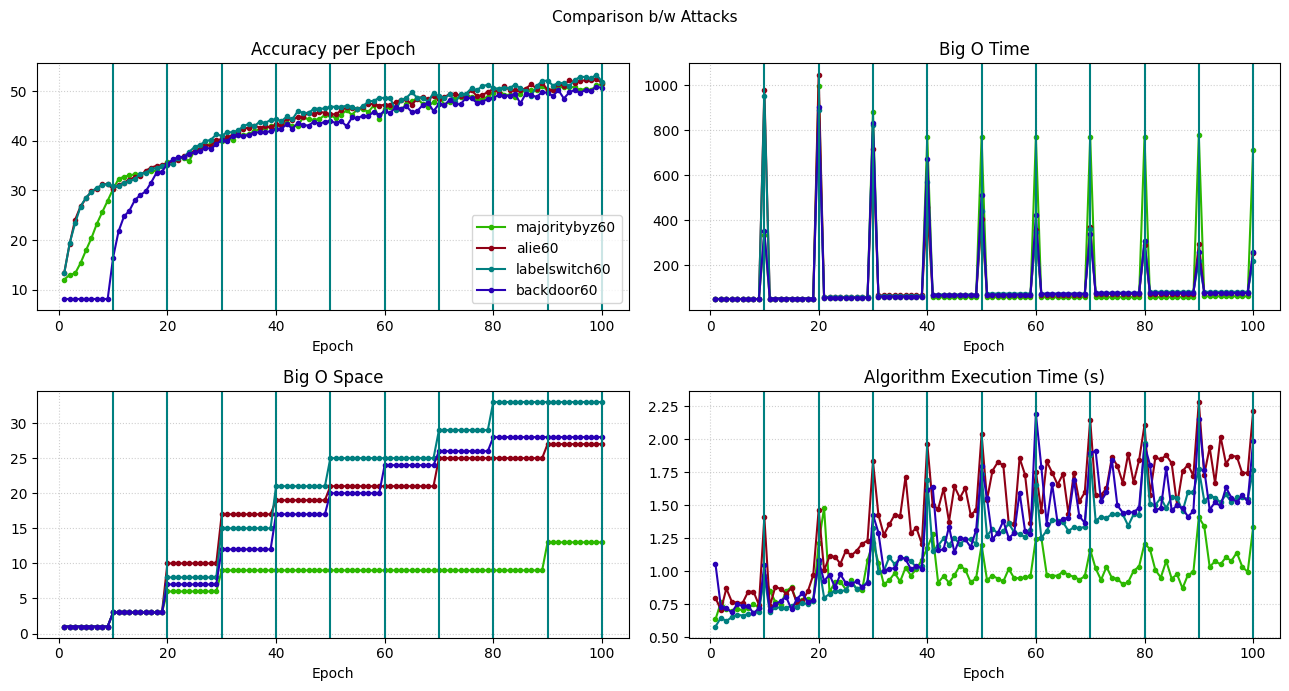

In [55]:
compare_attacks(
    attack=("majoritybyz60", "alie60", "labelswitch60", "backdoor60"), 
    protocol="fedattract", 
    data_type="d1", 
    steps_split_fedattract=10
)

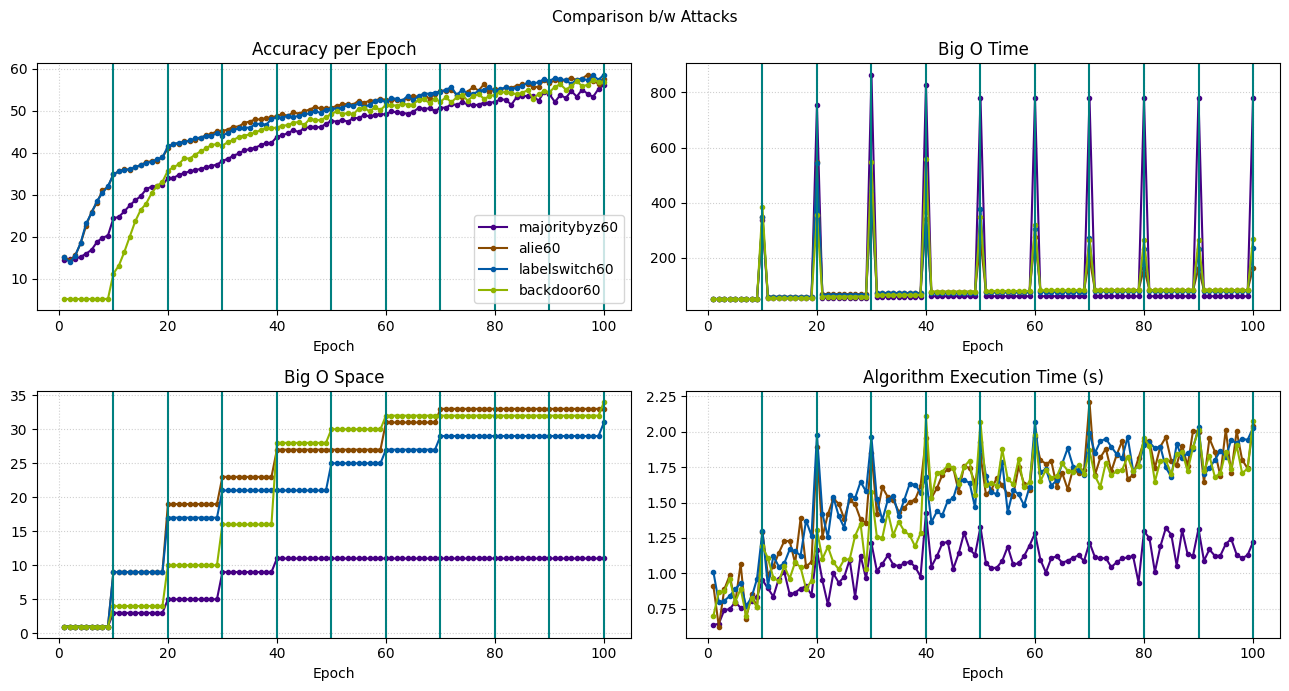

In [57]:
compare_attacks(
    attack=("majoritybyz60", "alie60", "labelswitch60", "backdoor60"), 
    protocol="fedattract", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

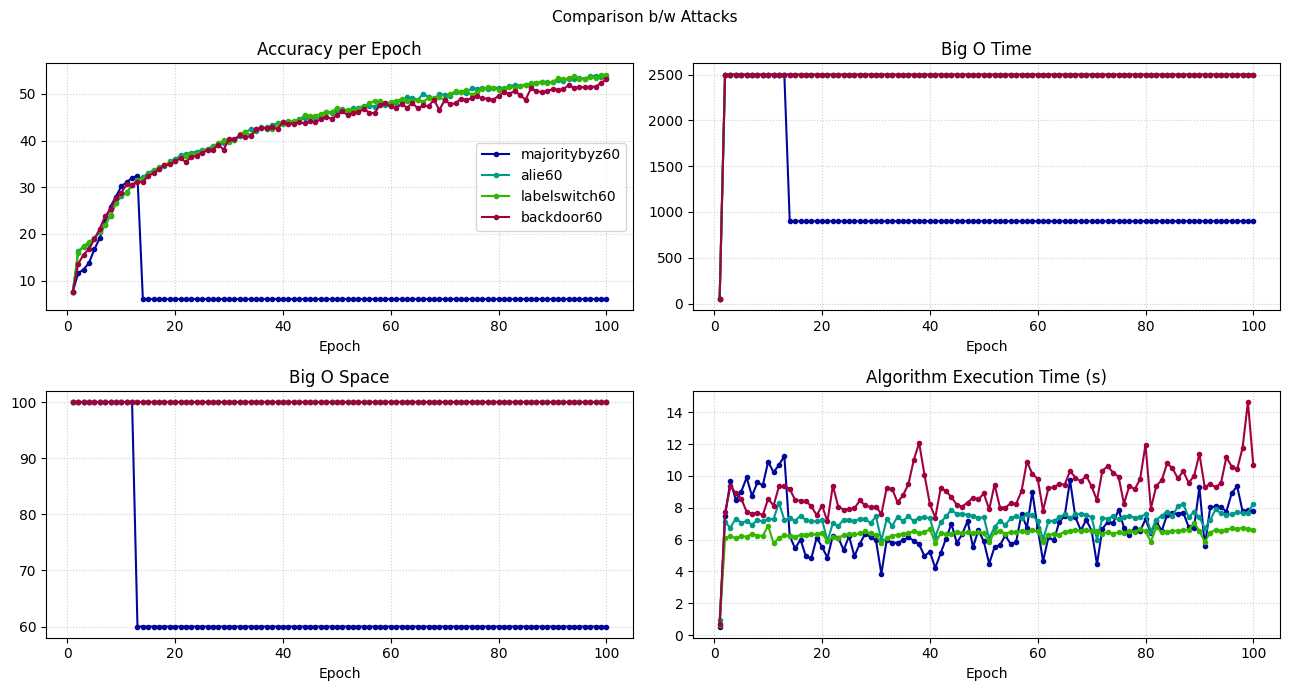

In [58]:
compare_attacks(
    attack=("majoritybyz60", "alie60", "labelswitch60", "backdoor60"), 
    protocol="cap", 
    data_type="d1", 
    steps_split_fedattract=10
)

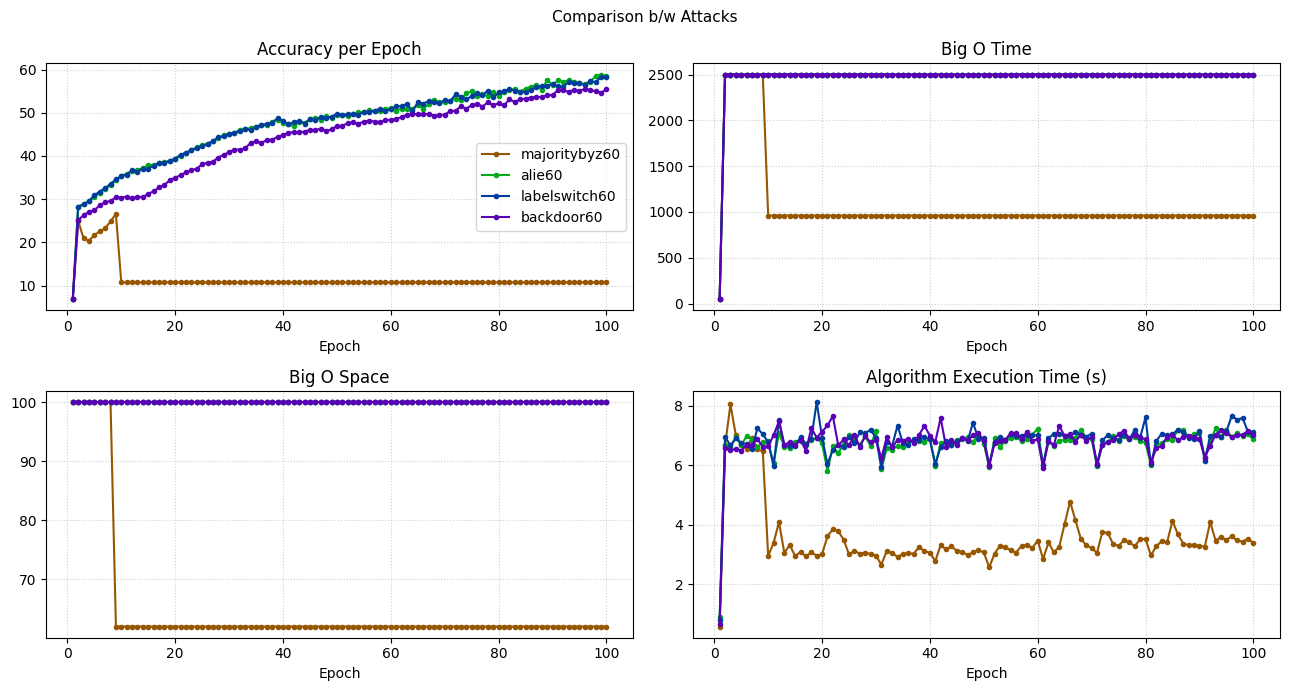

In [59]:
compare_attacks(
    attack=("majoritybyz60", "alie60", "labelswitch60", "backdoor60"), 
    protocol="cap", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

In [60]:
##############################################################

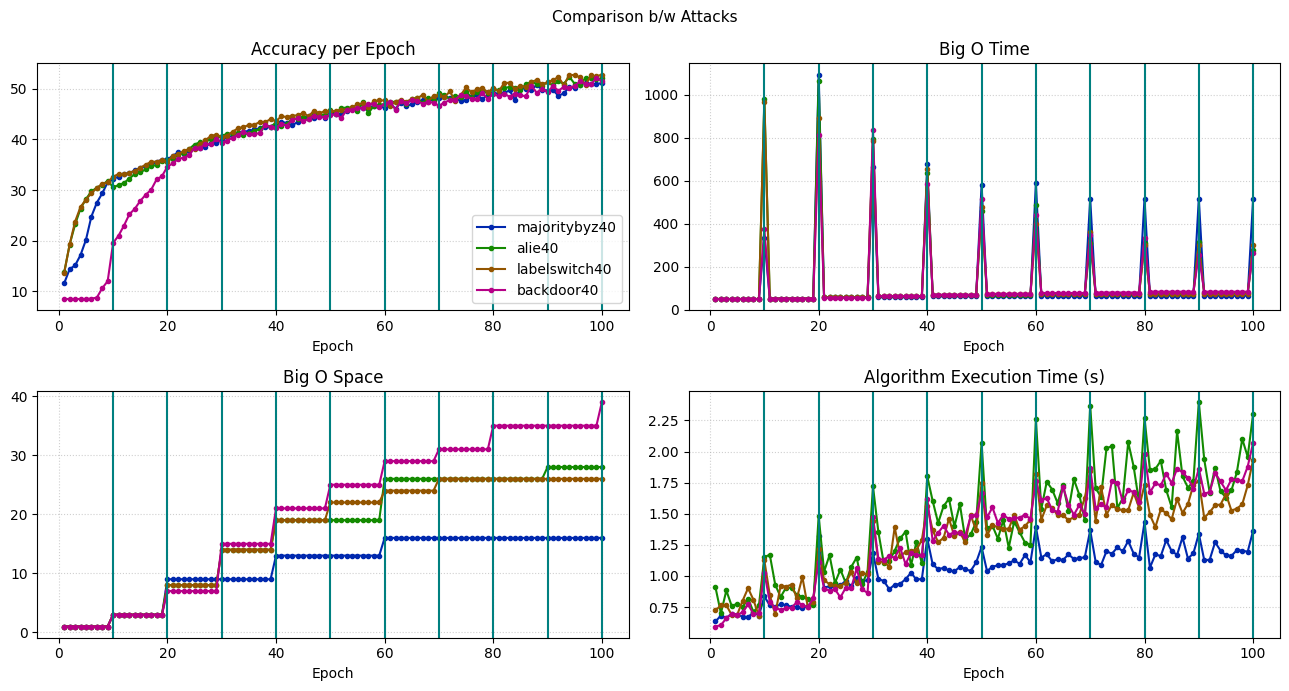

In [61]:
compare_attacks(
    attack=("majoritybyz40", "alie40", "labelswitch40", "backdoor40"), 
    protocol="fedattract", 
    data_type="d1", 
    steps_split_fedattract=10
)

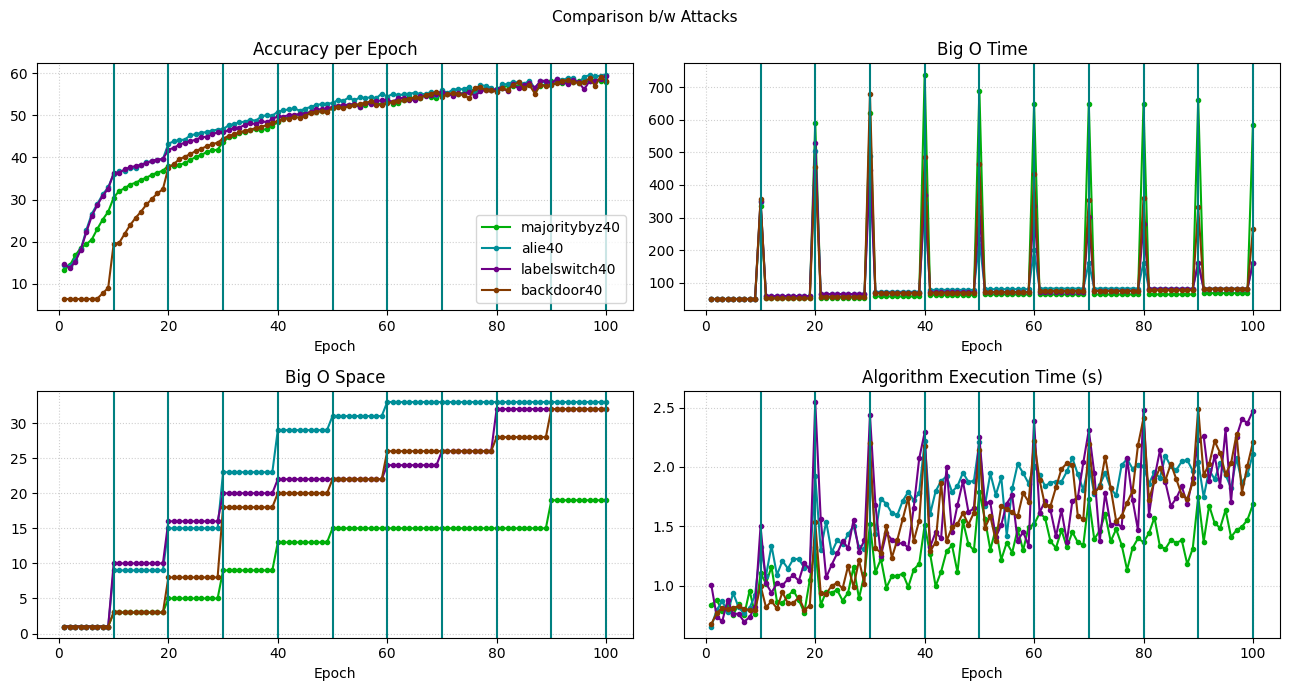

In [63]:
compare_attacks(
    attack=("majoritybyz40", "alie40", "labelswitch40", "backdoor40"), 
    protocol="fedattract", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

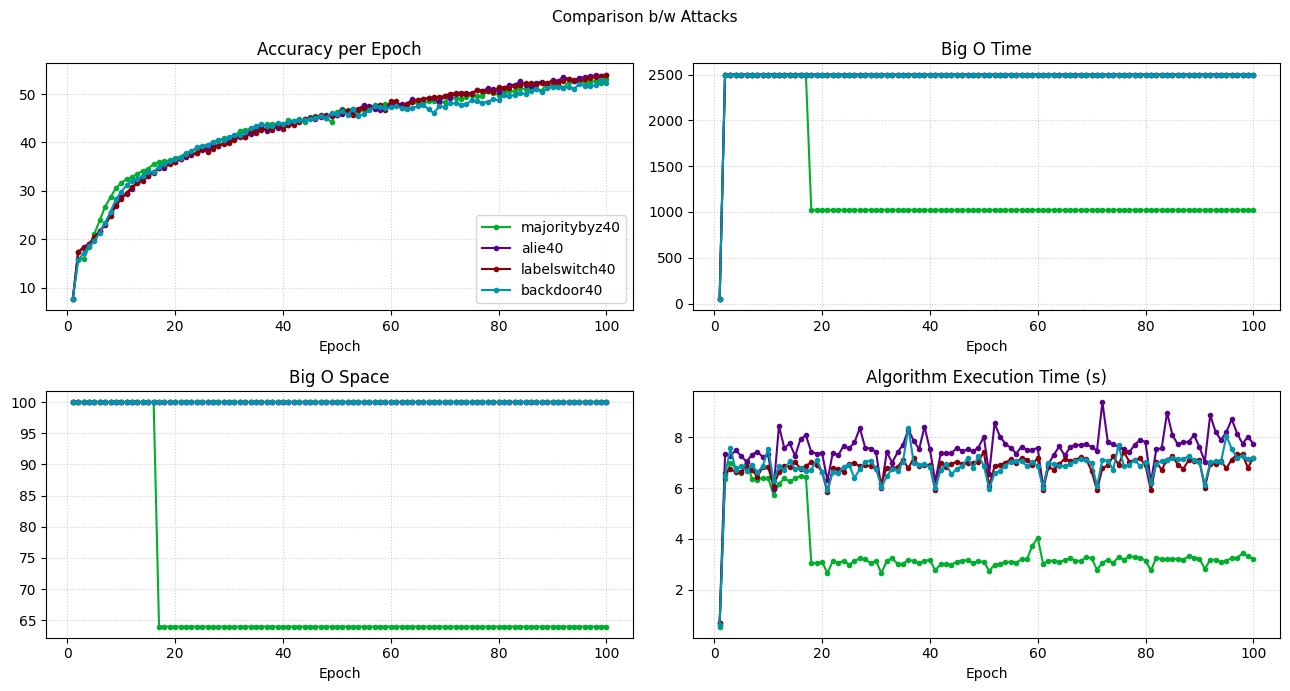

In [64]:
compare_attacks(
    attack=("majoritybyz40", "alie40", "labelswitch40", "backdoor40"), 
    protocol="cap", 
    data_type="d1", 
    steps_split_fedattract=10
)

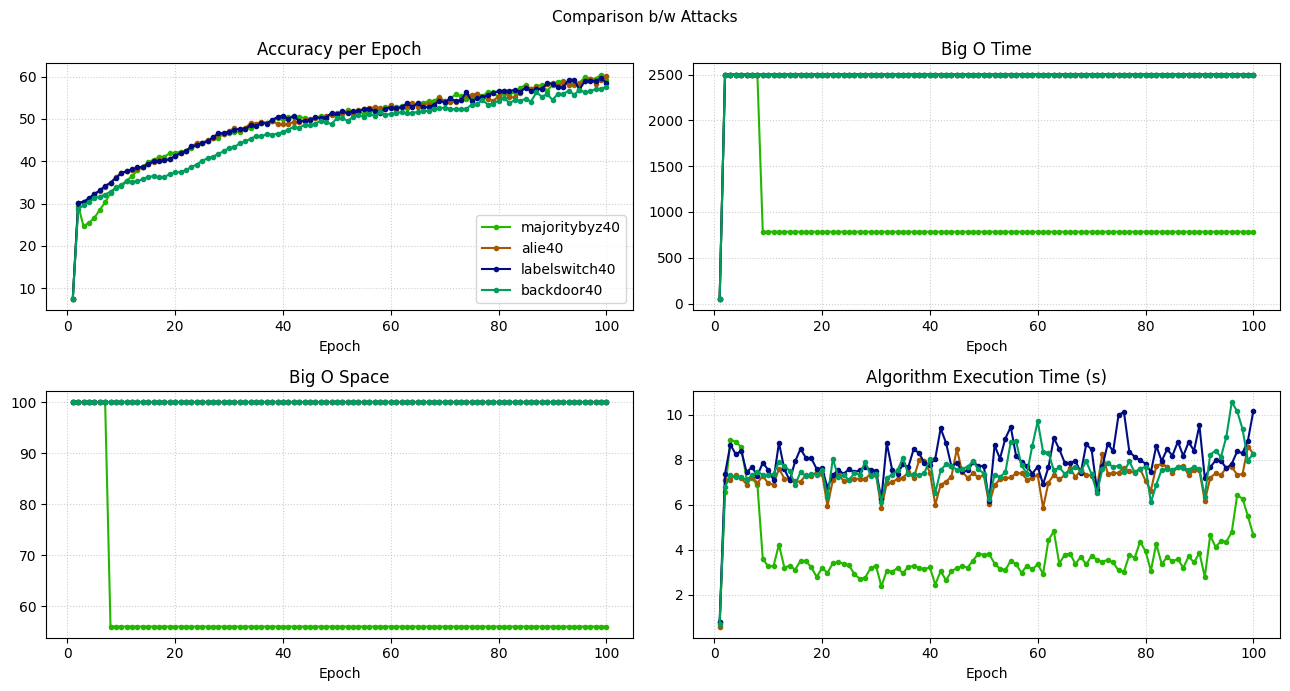

In [65]:
compare_attacks(
    attack=("majoritybyz40", "alie40", "labelswitch40", "backdoor40"), 
    protocol="cap", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

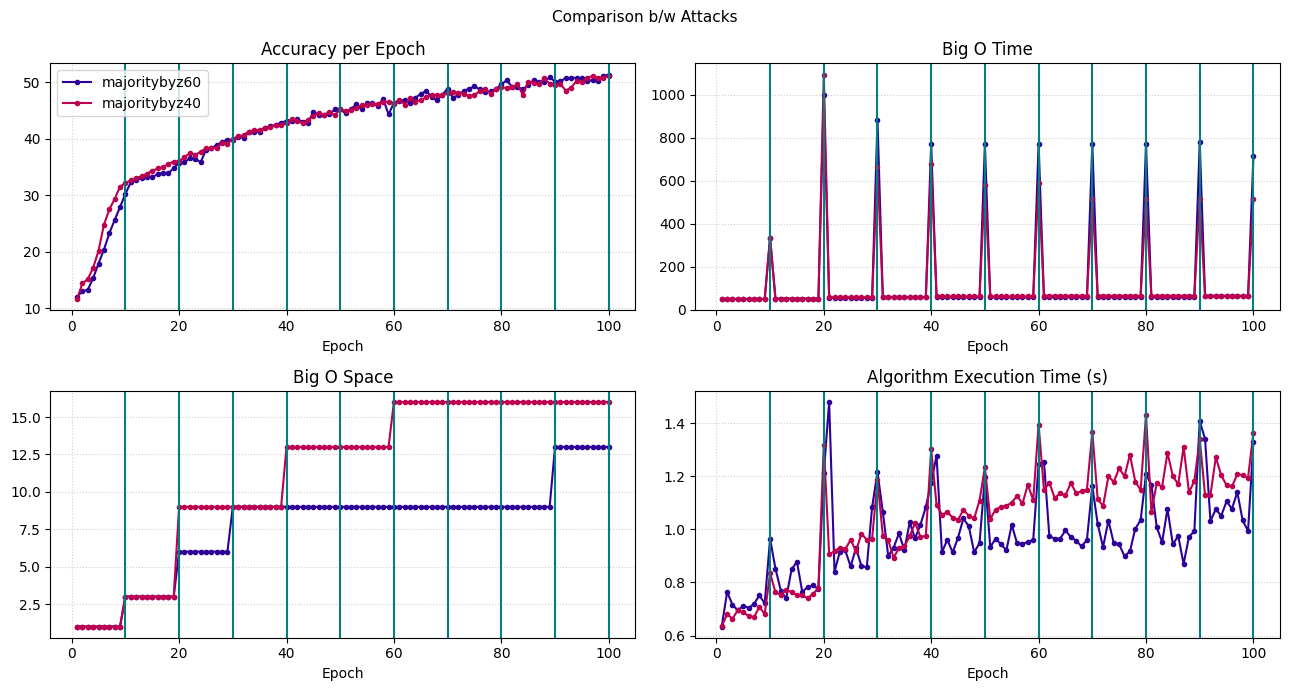

In [36]:
compare_attacks(
    attack=("majoritybyz60", "majoritybyz40"), 
    protocol="fedattract", 
    data_type="d1", 
    steps_split_fedattract=10
)

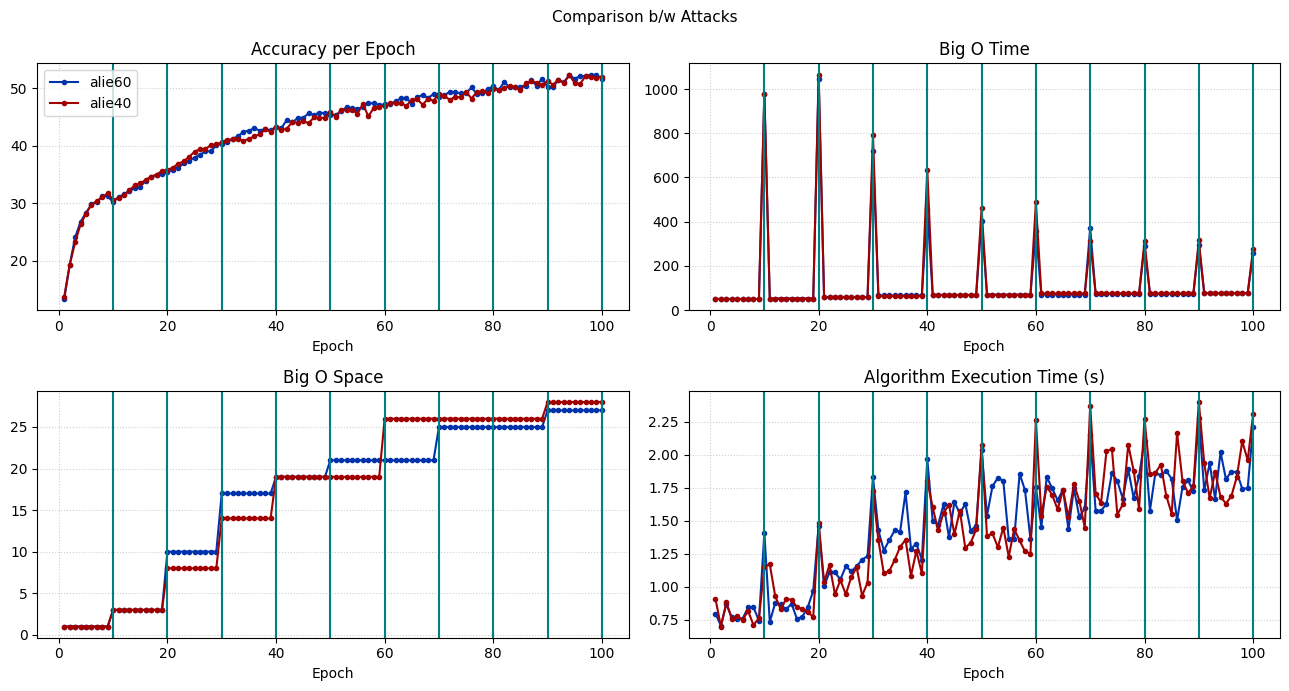

In [37]:
compare_attacks(
    attack=("alie60", "alie40"), 
    protocol="fedattract", 
    data_type="d1", 
    steps_split_fedattract=10
)

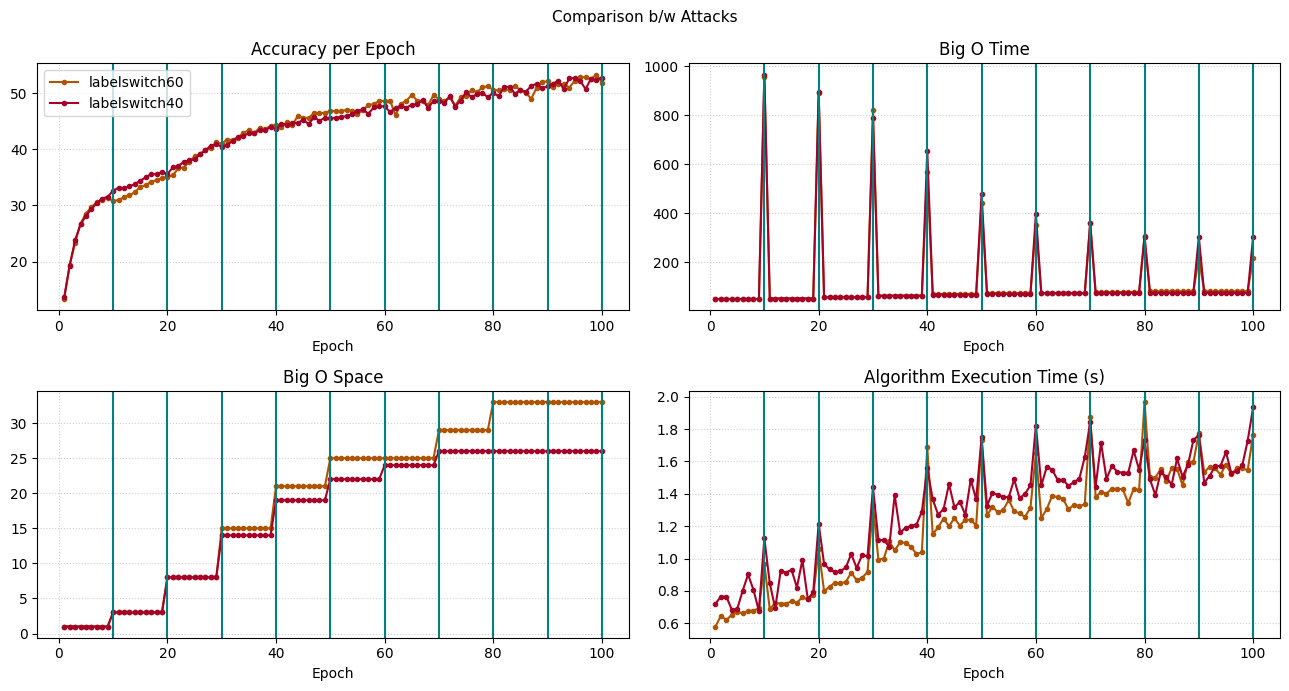

In [38]:
compare_attacks(
    attack=("labelswitch60", "labelswitch40"), 
    protocol="fedattract", 
    data_type="d1", 
    steps_split_fedattract=10
)

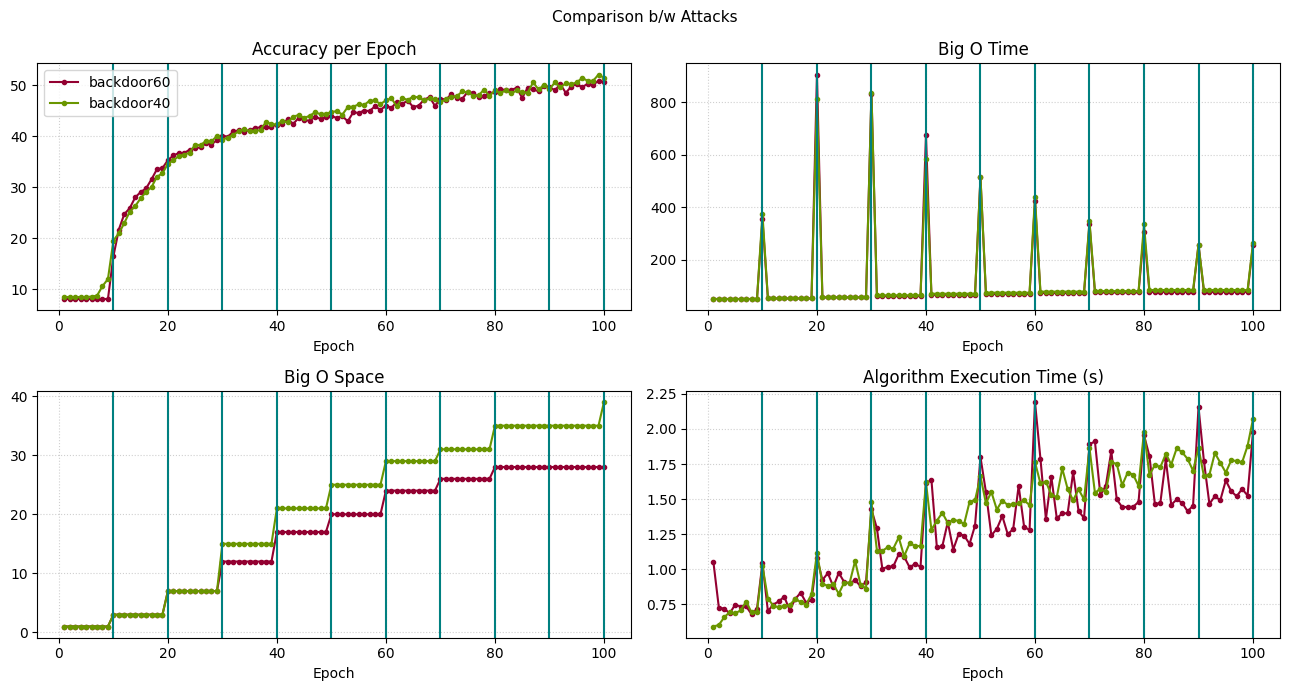

In [39]:
compare_attacks(
    attack=("backdoor60", "backdoor40"), 
    protocol="fedattract", 
    data_type="d1", 
    steps_split_fedattract=10
)

In [106]:
#############################################################

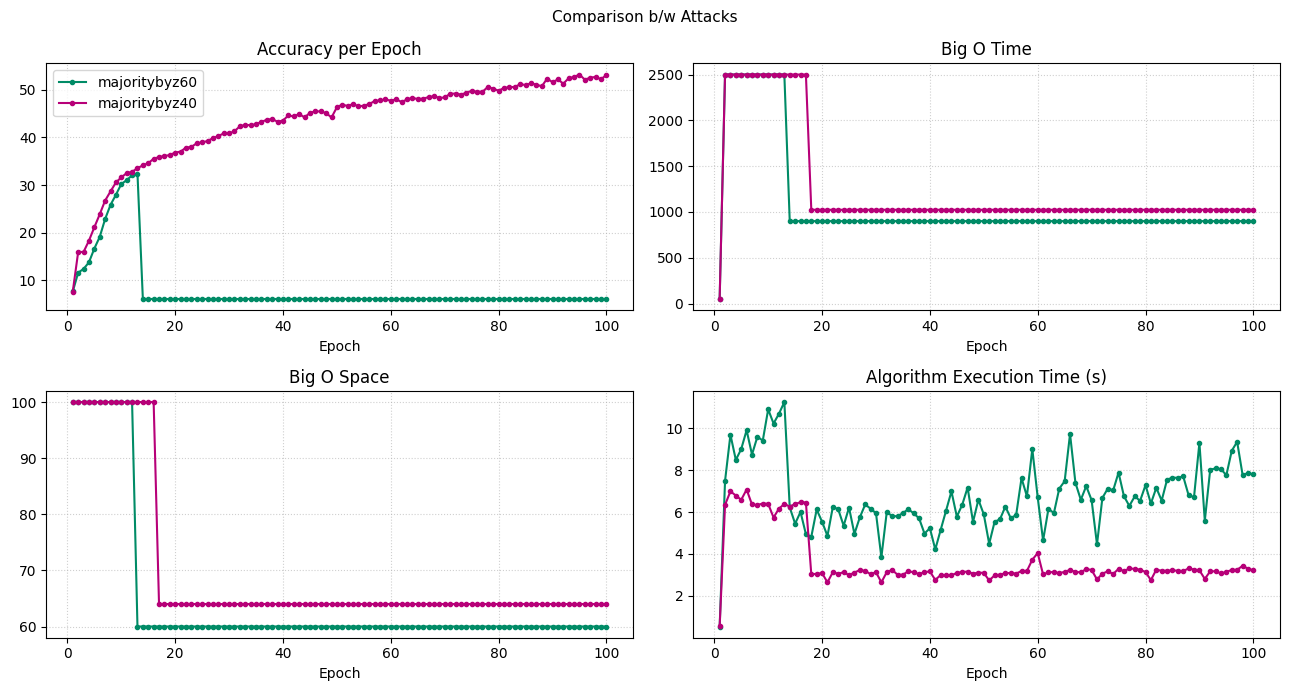

In [40]:
compare_attacks(
    attack=("majoritybyz60", "majoritybyz40"), 
    protocol="cap", 
    data_type="d1", 
    steps_split_fedattract=10
)

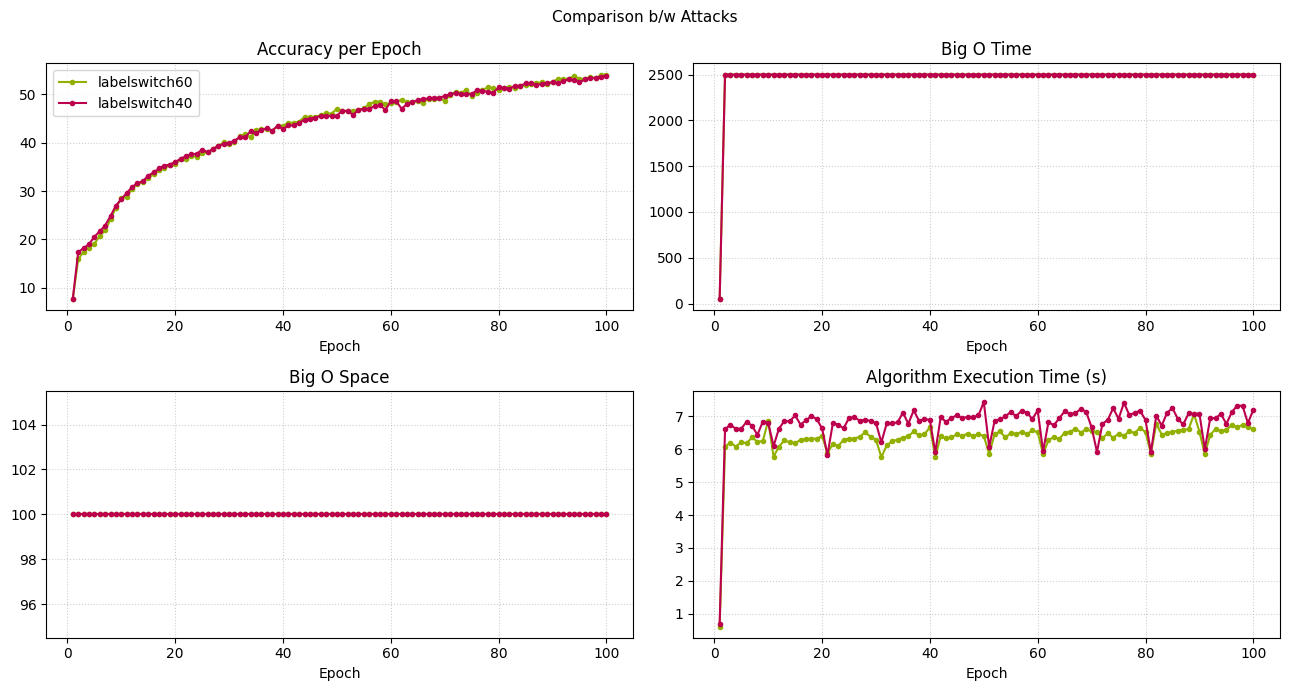

In [41]:
compare_attacks(
    attack=("labelswitch60", "labelswitch40"), 
    protocol="cap", 
    data_type="d1", 
    steps_split_fedattract=10
)

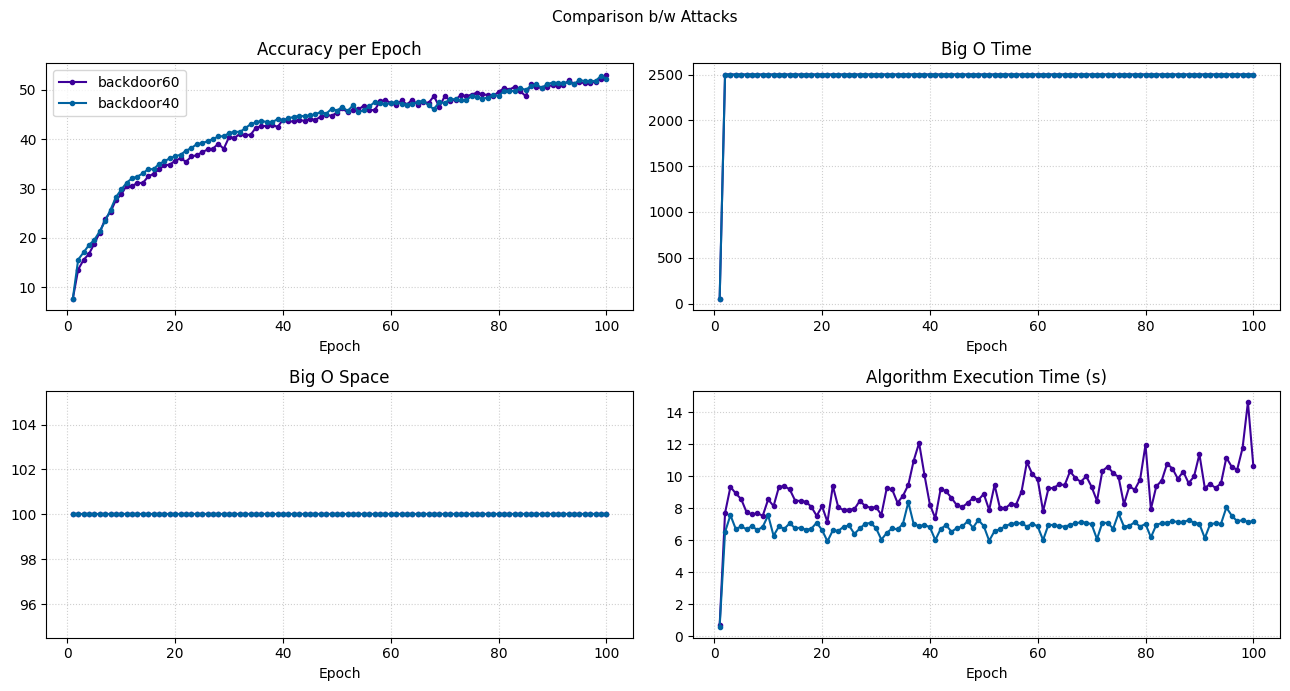

In [42]:
compare_attacks(
    attack=("backdoor60", "backdoor40"), 
    protocol="cap", 
    data_type="d1", 
    steps_split_fedattract=10
)

In [130]:
#################################################################################
#################################################################################
#################################################################################
#################################################################################

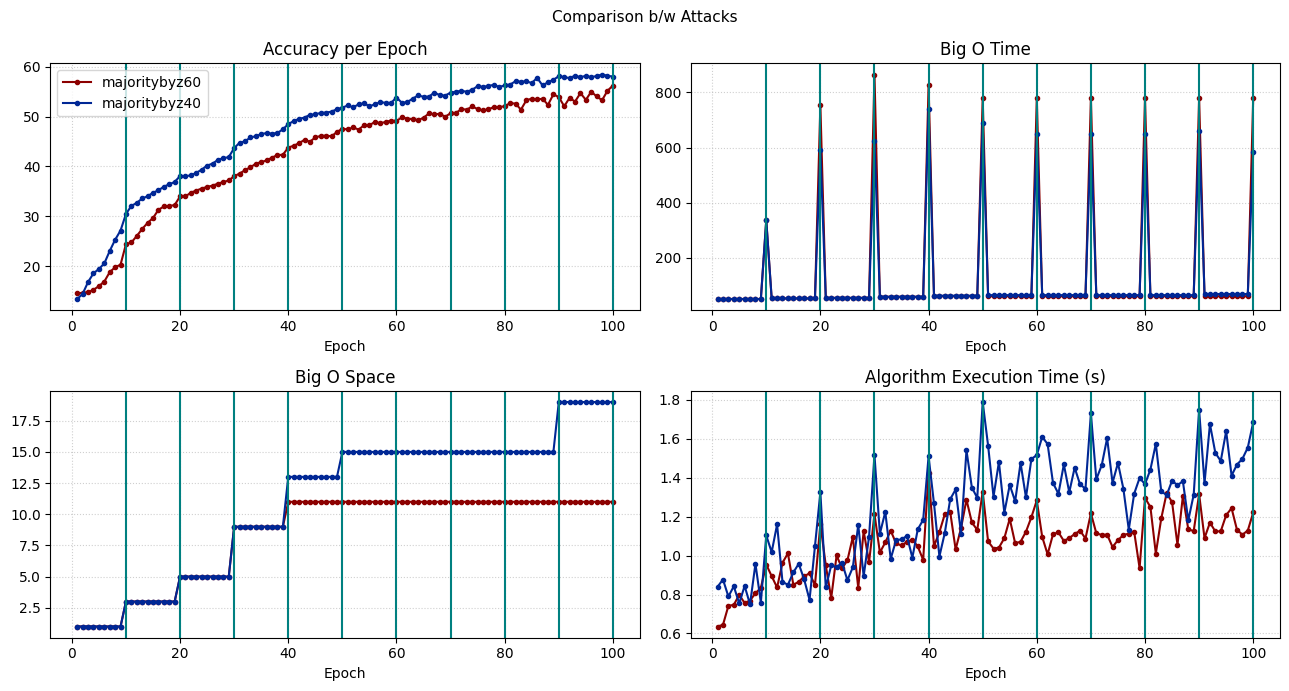

In [43]:
compare_attacks(
    attack=("majoritybyz60", "majoritybyz40"), 
    protocol="fedattract", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

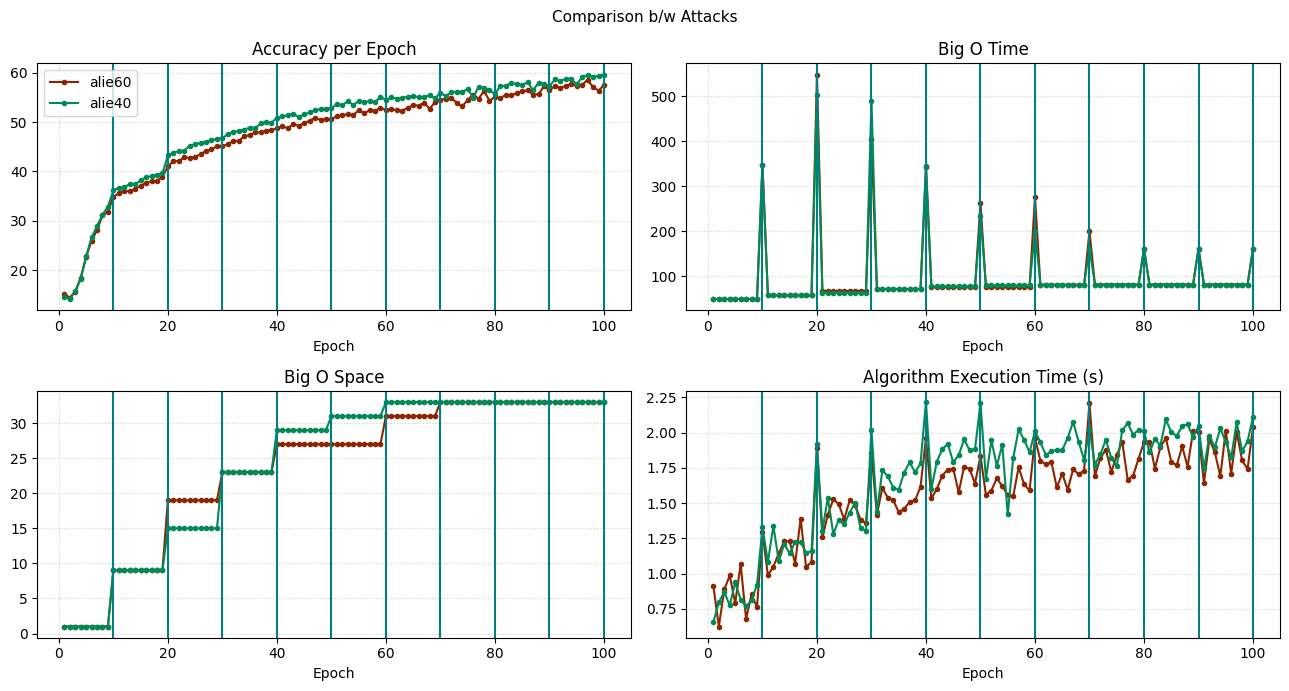

In [46]:
compare_attacks(
    attack=("alie60", "alie40"), 
    protocol="fedattract", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

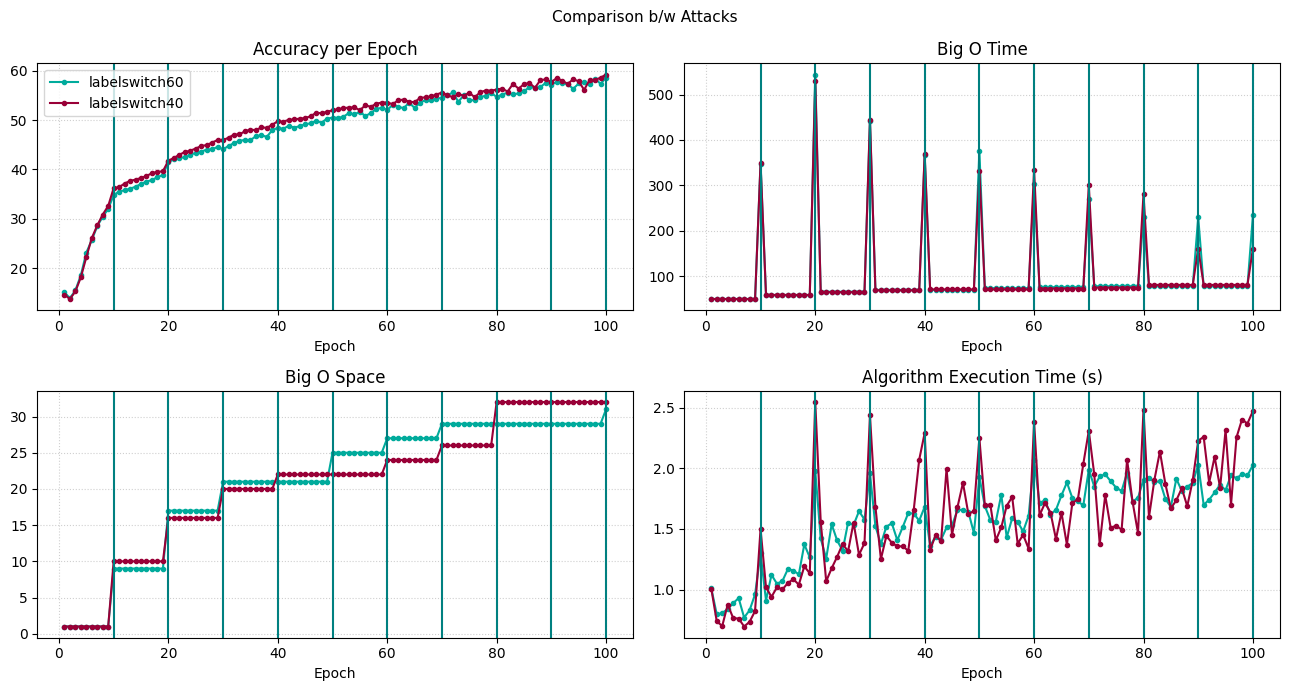

In [47]:
compare_attacks(
    attack=("labelswitch60", "labelswitch40"), 
    protocol="fedattract", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

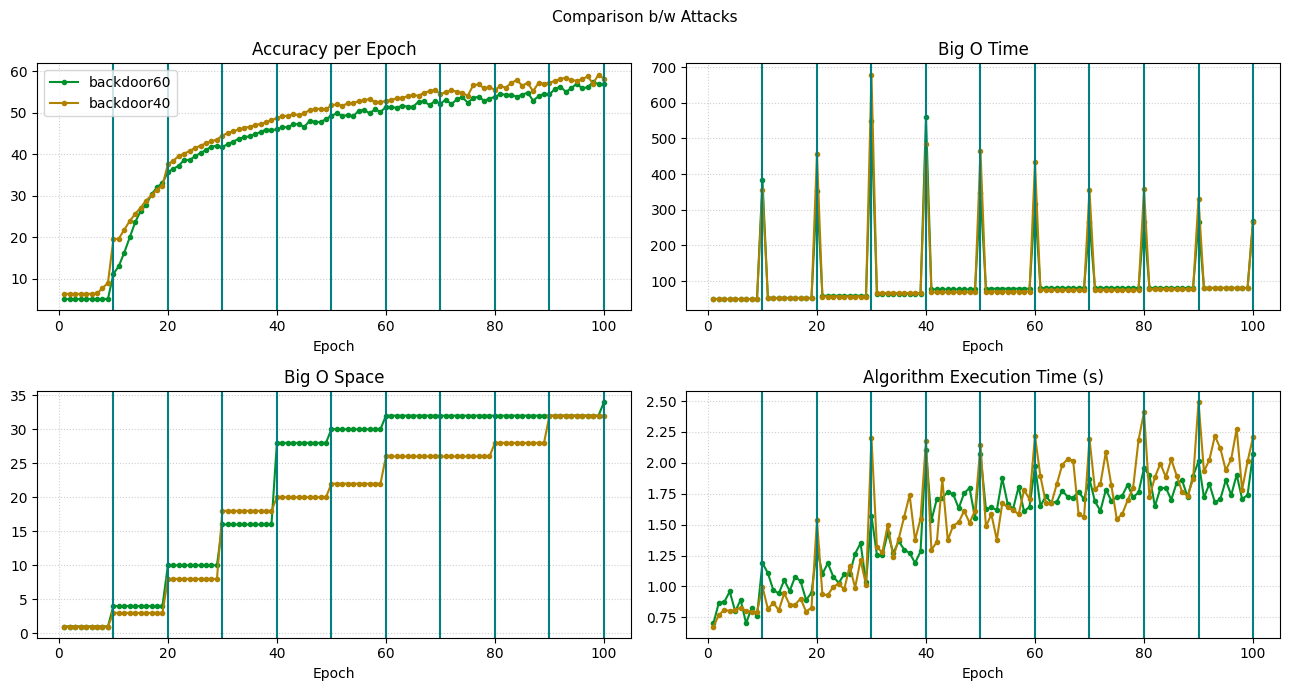

In [48]:
compare_attacks(
    attack=("backdoor60", "backdoor40"), 
    protocol="fedattract", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

In [139]:
#############################################################

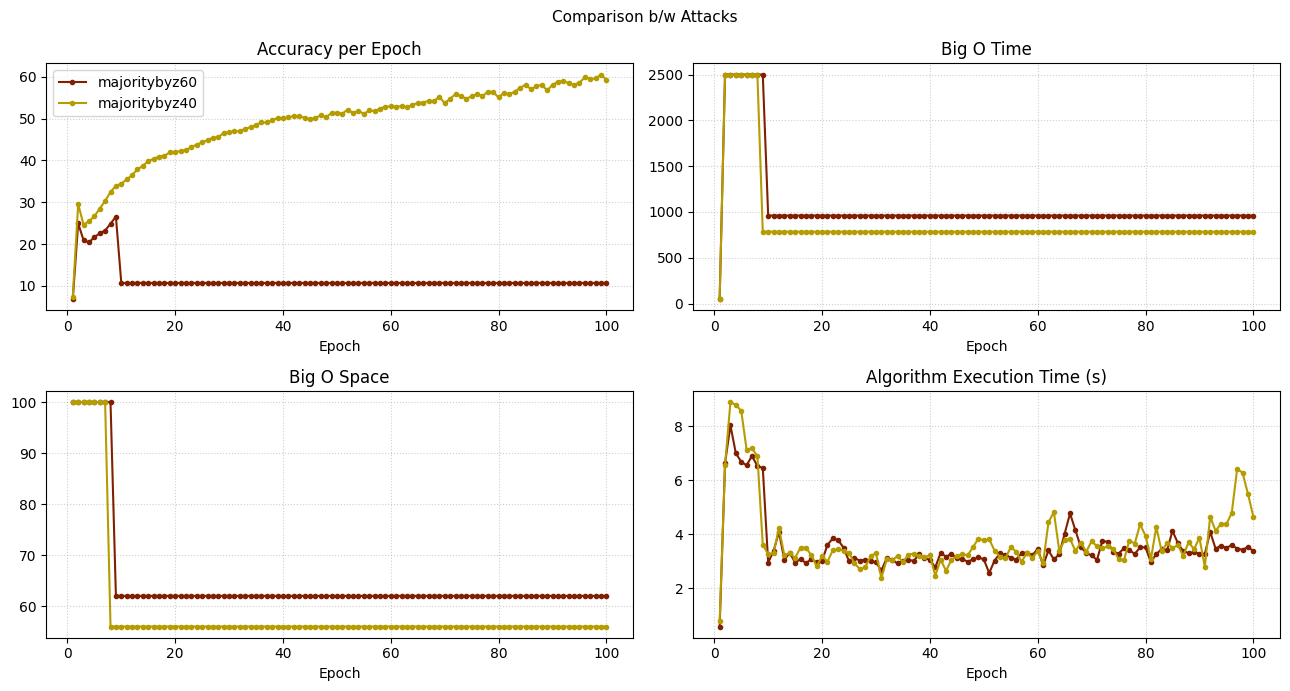

In [49]:
compare_attacks(
    attack=("majoritybyz60", "majoritybyz40"), 
    protocol="cap", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

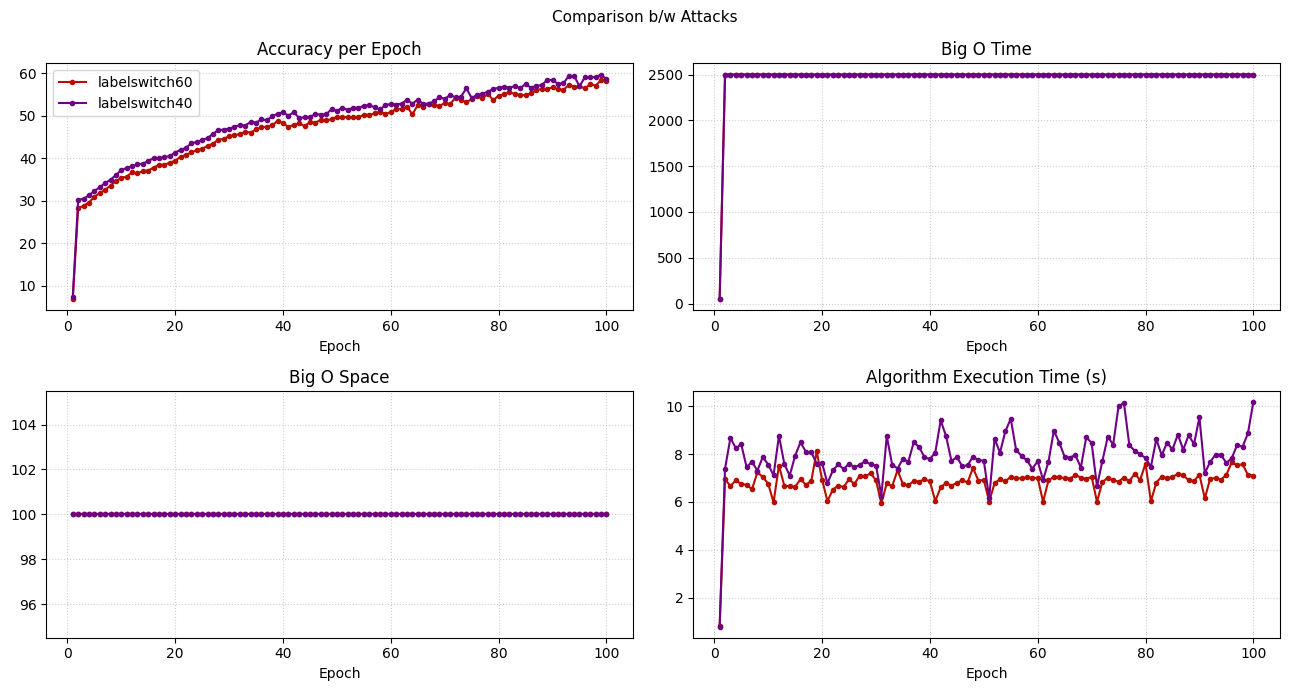

In [50]:
compare_attacks(
    attack=("labelswitch60", "labelswitch40"), 
    protocol="cap", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

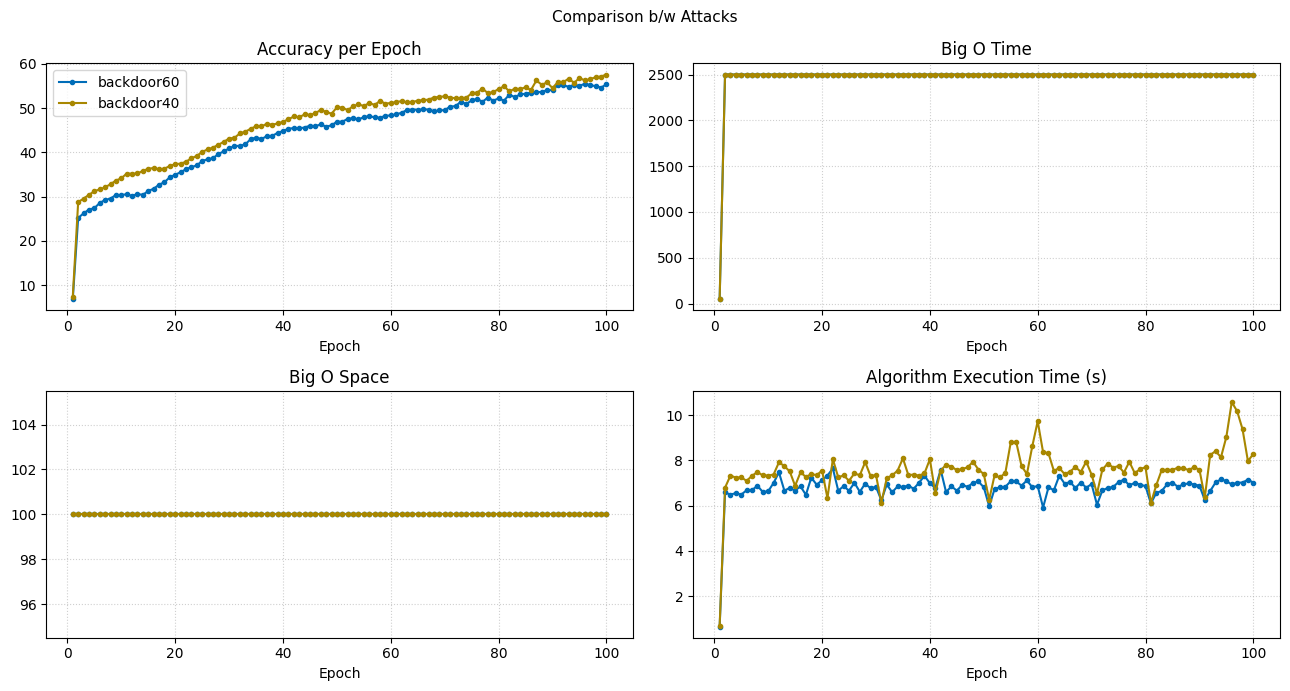

In [51]:
compare_attacks(
    attack=("backdoor60", "backdoor40"), 
    protocol="cap", 
    data_type="pathalogical", 
    steps_split_fedattract=10
)

In [160]:
############################################
# LATE ATTACKS
############################################

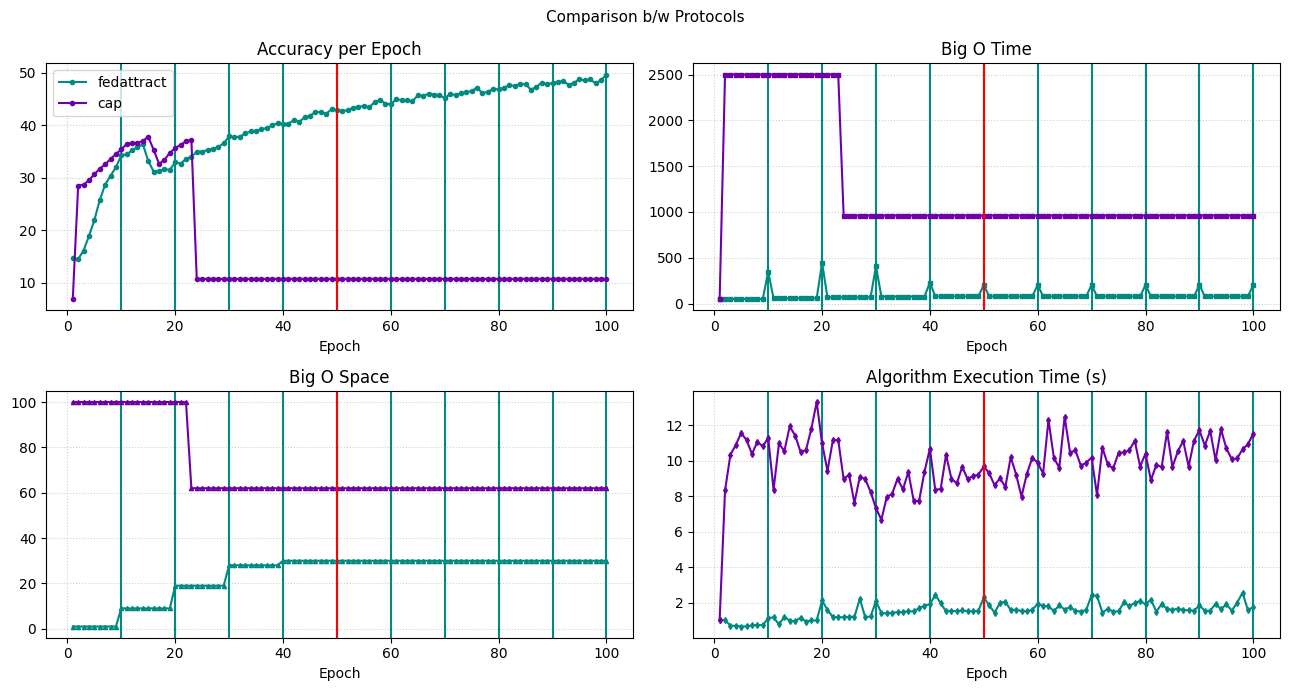

In [44]:
compare_protocols(attack="late_majoritybyz60", protocol=("fedattract", "cap"), data_type="pathalogical", steps_split_fedattract=[10, 0])

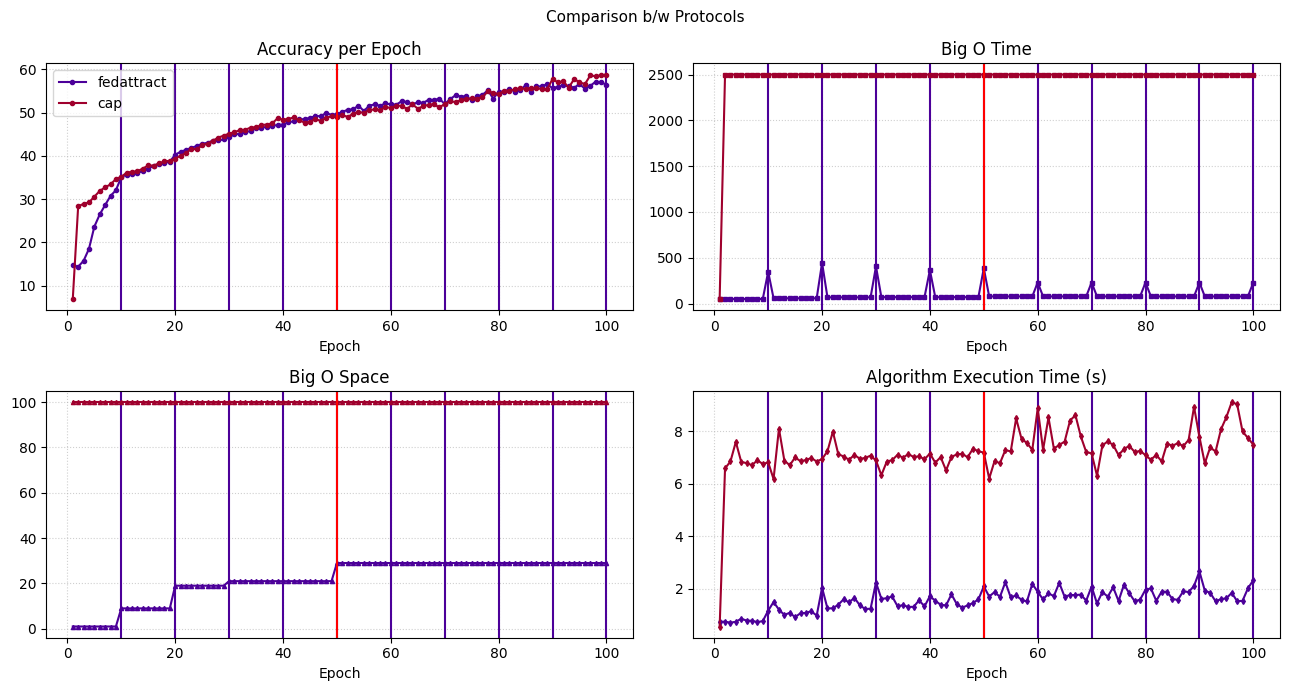

In [46]:
compare_protocols(attack="late_alie60", protocol=("fedattract", "cap"), data_type="pathalogical", steps_split_fedattract=[10, 0])

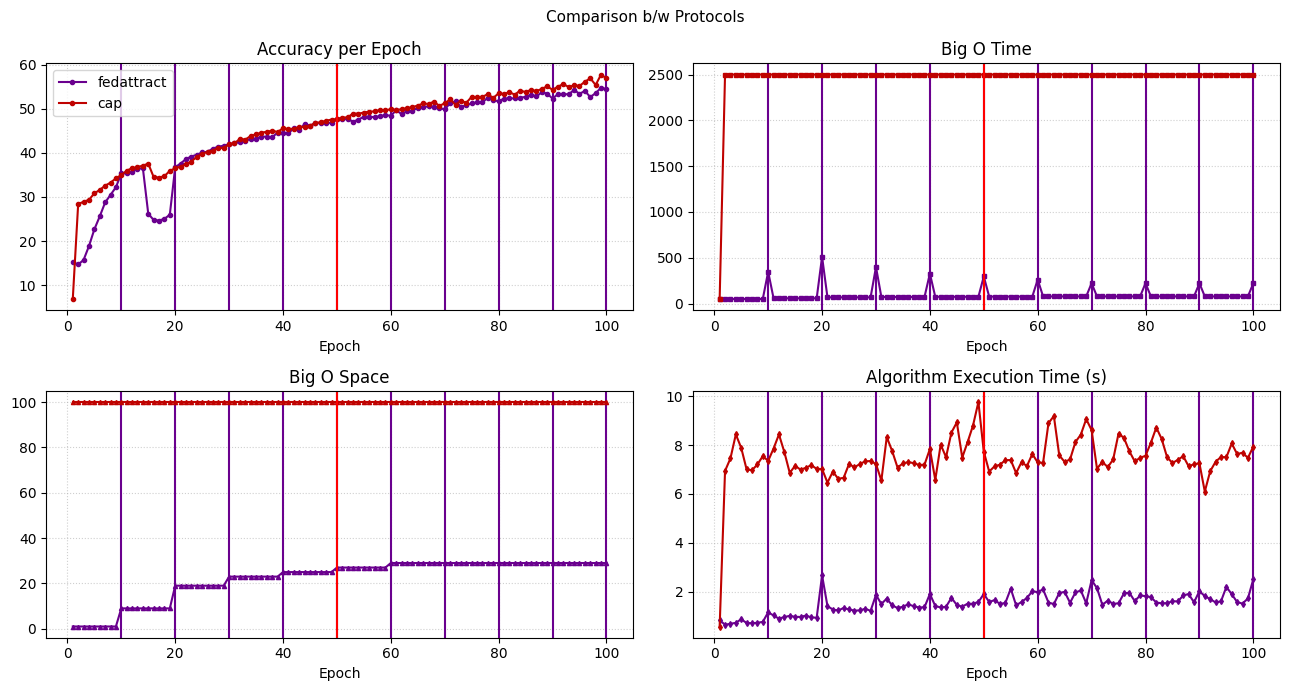

In [47]:
compare_protocols(attack="late_backdoor60", protocol=("fedattract", "cap"), data_type="pathalogical", steps_split_fedattract=[10, 0])

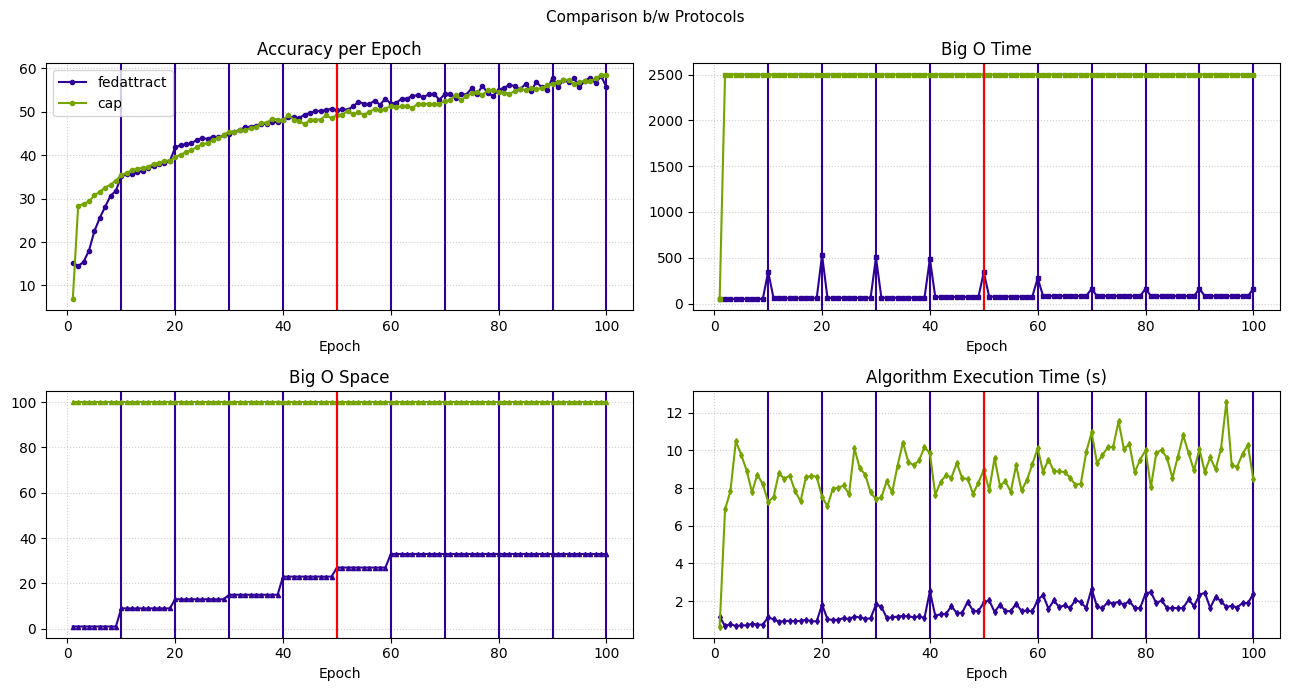

In [48]:
compare_protocols(attack="late_labelswitch60", protocol=("fedattract", "cap"), data_type="pathalogical", steps_split_fedattract=[10, 0])

In [102]:
analyze_run(attack="majoritybyz60", protocol="fedattract", data_type="d1", return_only='bigo')

0      50
1      50
2      50
3      50
4      50
     ... 
95     62
96     62
97     62
98     62
99    714
Name: bigo_time, Length: 100, dtype: int64